In [31]:
from tensorflow import keras

model_rnn = keras.models.load_model('/kaggle/input/final-path-prediction-models/Simple_RNN-500-epochs_RELU_4layer-model.h5')
model_bilstm = keras.models.load_model('/kaggle/input/final-path-prediction-models/FINAL_BiLSTM-500-epochs-TANH-3Layer-model.h5')
model_gru = keras.models.load_model('/kaggle/input/final-path-prediction-models/FINAL_GRU-500-epochs-TANH-3Layer-model.h5')

In [32]:
import numpy as np
lat_in = [10, 10.0925, 10.2, 10.335, 10.5, 10.6925, 10.9, 10.974, 11.2, 11.5243, 11.7, 11.9806, 12.25, 12.4, 12.8, 12.9787, 13.3, 13.575, 13.85, 14.1712, 14.45, 14.685, 15]
lon_in = [70.9, 71.1225, 71.3, 71.4075, 71.5, 71.6425, 71.8, 72.014, 72.2333, 72.3814, 72.55, 72.6631, 72.75, 72.8325, 72.85, 72.9187, 73, 73.015, 72.95, 72.9, 72.8, 72.7888, 72.75]
latn = np.array([float(numeric_string) for numeric_string in lat_in])
lonn = np.array([float(numeric_string) for numeric_string in lon_in])
# Dividing by max value of lat/long
latn= latn/90
lonn= lonn/90

In [33]:
ts=np.vstack((latn,lonn)).T 

In [34]:
ts = ts.reshape(1, 23, 2)

In [35]:
ts

array([[[0.11111111, 0.78777778],
        [0.11213889, 0.79025   ],
        [0.11333333, 0.79222222],
        [0.11483333, 0.79341667],
        [0.11666667, 0.79444444],
        [0.11880556, 0.79602778],
        [0.12111111, 0.79777778],
        [0.12193333, 0.80015556],
        [0.12444444, 0.80259222],
        [0.12804778, 0.80423778],
        [0.13      , 0.80611111],
        [0.13311778, 0.80736778],
        [0.13611111, 0.80833333],
        [0.13777778, 0.80925   ],
        [0.14222222, 0.80944444],
        [0.14420778, 0.81020778],
        [0.14777778, 0.81111111],
        [0.15083333, 0.81127778],
        [0.15388889, 0.81055556],
        [0.15745778, 0.81      ],
        [0.16055556, 0.80888889],
        [0.16316667, 0.80876444],
        [0.16666667, 0.80833333]]])

In [36]:
yhat_rnn = model_rnn.predict(ts) 
yhat_bi = model_bilstm.predict(ts) 
yhat_gru = model_gru.predict(ts) 

1/1 [==============================] - 1s 826ms/step


In [37]:
print(yhat_rnn)
print(yhat_bi)
print(yhat_gru)

[[[0.17275989 0.79739165]
  [0.17131174 0.79501873]
  [0.17351335 0.79918075]
  [0.17462017 0.8003968 ]
  [0.17810367 0.8010457 ]
  [0.18062256 0.7997505 ]
  [0.18315583 0.7999501 ]
  [0.1850119  0.7996368 ]
  [0.18621875 0.79947   ]
  [0.18760073 0.7995173 ]
  [0.18849918 0.799402  ]
  [0.18908066 0.7995659 ]]]
[[[0.1773701  0.81116533]
  [0.17916316 0.81081116]
  [0.18117009 0.8099929 ]
  [0.18302631 0.80816793]
  [0.18481994 0.80675554]
  [0.18672974 0.8055097 ]
  [0.18863133 0.80397034]
  [0.1905477  0.80232275]
  [0.19275472 0.8012028 ]
  [0.19521381 0.80069804]
  [0.19738308 0.79918635]
  [0.1994241  0.79851353]]]
[[[0.17198688 0.81353855]
  [0.17440328 0.8126829 ]
  [0.1769017  0.8118906 ]
  [0.17911091 0.81070554]
  [0.18149862 0.8093472 ]
  [0.1837936  0.80796146]
  [0.18591836 0.80658144]
  [0.18785936 0.80529845]
  [0.18960702 0.8041142 ]
  [0.19115365 0.80295366]
  [0.19249049 0.80177695]
  [0.19360523 0.8006671 ]]]


In [47]:
x_act = [15.3637, 15.8, 16.2713, 16.75, 17.265, 17.65, 18.025, 18.4, 18.7925, 19.25, 19.6199, 20.05]
y_act = [72.7823, 72.8, 72.6725, 72.5, 72.2676, 72, 71.7886, 71.65, 71.6, 71.5, 71.45, 71.35]
x = lat_in + x_act
y = lon_in + y_act
x1 = []
x2 = []
x3 = []
y1 = []
y2 = []
y3 = []

for i in range(12):
    x1.append(yhat_rnn[0][i][0]*90)
    x2.append(yhat_bi[0][i][0]*90)
    x3.append(yhat_gru[0][i][0]*90)
    y1.append(yhat_rnn[0][i][1]*90)
    y2.append(yhat_bi[0][i][1]*90)
    y3.append(yhat_gru[0][i][1]*90)

x1f = lat_in + x1
x2f = lat_in + x2
x3f = lat_in + x3
y1f = lon_in + y1
y2f = lon_in + y2
y3f = lon_in + y3

In [50]:
y

[70.9,
 71.1225,
 71.3,
 71.4075,
 71.5,
 71.6425,
 71.8,
 72.014,
 72.2333,
 72.3814,
 72.55,
 72.6631,
 72.75,
 72.8325,
 72.85,
 72.9187,
 73,
 73.015,
 72.95,
 72.9,
 72.8,
 72.7888,
 72.75,
 72.7823,
 72.8,
 72.6725,
 72.5,
 72.2676,
 72,
 71.7886,
 71.65,
 71.6,
 71.5,
 71.45,
 71.35]

In [53]:
x3f

[10,
 10.0925,
 10.2,
 10.335,
 10.5,
 10.6925,
 10.9,
 10.974,
 11.2,
 11.5243,
 11.7,
 11.9806,
 12.25,
 12.4,
 12.8,
 12.9787,
 13.3,
 13.575,
 13.85,
 14.1712,
 14.45,
 14.685,
 15,
 15.478819012641907,
 15.696295201778412,
 15.921152830123901,
 16.119982302188873,
 16.334875524044037,
 16.54142439365387,
 16.732652485370636,
 16.907342076301575,
 17.064632177352905,
 17.20382809638977,
 17.324143946170807,
 17.424470633268356]

In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv('/kaggle/input/cyclone-paths-ibtracs-north-indian-ocean/ibtracs.NI.list.v04r00.csv')

timeseries = df.loc[:,["SID","LAT","LON"]].values
sid=timeseries[:,0]
lat=timeseries[:,1]
lon=timeseries[:,2]

sid=np.delete(sid,0)
lon = np.delete(lon,0)
lat = np.delete(lat,0)

latn = np.array([float(numeric_string) for numeric_string in lat])
lonn = np.array([float(numeric_string) for numeric_string in lon])
ts=np.vstack((sid,latn,lonn)).T 

z=[];
k=-1;
p=ts.shape[0]
data=[]
for t in range(0,p):
  if ts[t][0] not in z:
    k=k+1;
#     print(k);
    data.append([]);
    data[k].append(ts[t]);
    z.append(ts[t][0]);
  else:
    data[k].append(ts[t]);
    
sizes=[]

for j in range(0,200):
  sizes.append(0);

for k in range(0,len(data)):
  sizes[len(data[k])]= sizes[len(data[k])] + 1;

newdata=[]
for j in range(0,len(data)):
  if len(data[j]) >= 18 and len(data[j]) <= 35:
    newdata.append(data[j])
  elif (len(data[j]) > 35):
    newdata.append(data[j][:35])
    
t=0;
mod_data=[];
for j in range(0,len(newdata)):
    t=0;
    n=len(newdata[j])
    mod_data.append([])
    for k in range (0,n):
        
        mod_data[j].append([newdata[j][t][0],newdata[j][t][1],newdata[j][t][2] ] );
        if k<(35-n):

        f=float((newdata[j][t][1]+newdata[j][t+1][1])/2)
        g=float((newdata[j][t][2]+newdata[j][t+1][2])/2)

        mod_data[j].append(([newdata[j][t][0], f , g ]))
        t=t+1;
    
for j in range(0,len(mod_data)):
    for k in range(0, len(mod_data[j])):
        del(mod_data[j][k][0])
    
def split_sequences(sequences, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(0,len(sequences)):
    # gather input and output parts of the pattern
    seq_x, seq_y = sequences[i][:n_steps_in], sequences[i][n_steps_in : n_steps_out]
    X.append(seq_x)
    y.append(seq_y)
    return np.array(X), np.array(y)

n_past = 23
n_future = 35
#n_features = 7

# for j in range(0,len(mod_data)):
X, y = split_sequences(mod_data,n_past, n_future)

/tmp/ipykernel_31/46123920.py:3: DtypeWarning: Columns (1,2,8,9,14,161,162) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/kaggle/input/cyclone-paths-ibtracs-north-indian-ocean/ibtracs.NI.list.v04r00.csv')


In [28]:
from numpy import array
from numpy import hstack
n_features=2
n_steps_in, n_steps_out = 23, 12

def calPred(model):
    res=[]
    for c_index in range(0,len(X)):
        x_input = array(X[c_index])
        x_input = x_input.reshape((1, n_steps_in, n_features))
#         print(x_input.shape)
        yhat = model.predict(x_input, verbose=0)
        x1=[]
        y1=[]
        x2=[]
        y2=[]

        for j in range(0,len(y[c_index])):
          x1.append(y[c_index][j][0])
          y1.append(y[c_index][j][1])

        for j in range(0,len(yhat[0])):
          x2.append(yhat[0][j][0])
          y2.append(yhat[0][j][1])
        res.append([x1,y1,x2,y2])
    return res


In [30]:
rnn = calPred(model_rnn)
print(rnn[0])

KeyboardInterrupt: 

In [120]:
# r[58][1]

In [121]:
# r=calPred(model_bilstm)
# print(r)

In [122]:
# r=calPred(model_gru)
# print(r)

In [123]:
from numpy import array
from numpy import hstack
import matplotlib.pyplot as plt
import numpy as np
import math
n_features=2
n_steps_in, n_steps_out = 23, 12

def graphP(c_index):
    x_input = array(X[c_index])
    x_input = x_input.reshape((1, n_steps_in, n_features))
    yhat_rnn = model_rnn.predict(x_input, verbose=0)
    yhat_bilstm = model_bilstm.predict(x_input, verbose=0)
    yhat_gru = model_gru.predict(x_input, verbose=0)

    x1=[]
    y1=[]
    x2=[]
    y2=[]
    x3=[]
    y3=[]
    x4=[]
    y4=[]
    
    for j in range(0,len(X[c_index])):
        x1.append(X[c_index][j][0])
        y1.append(X[c_index][j][1])

    for j in range(0,len(y[c_index])):
        x1.append(y[c_index][j][0]/90)
        y1.append(y[c_index][j][1]/90)
    
    for j in range(0,len(X[c_index])):
        x2.append(X[c_index][j][0])
        y2.append(X[c_index][j][1])
        
    for j in range(0,len(yhat_rnn[0])):
        x2.append(yhat_rnn[0][j][0])
        y2.append(yhat_rnn[0][j][1])
        

    for j in range(0,len(X[c_index])):
        x3.append(X[c_index][j][0])
        y3.append(X[c_index][j][1])
        
    for j in range(0,len(yhat_bilstm[0])):
        x3.append(yhat_bilstm[0][j][0])
        y3.append(yhat_bilstm[0][j][1])

    for j in range(0,len(X[c_index])):
        x4.append(X[c_index][j][0])
        y4.append(X[c_index][j][1])
        
    for j in range(0,len(yhat_gru[0])):
        x4.append(yhat_gru[0][j][0])
        y4.append(yhat_gru[0][j][1])
        
    


    plt.plot(x1, y1, color='r', label='actual')
    plt.plot(x2, y2, color='g', label='rnn_predicted')
    plt.plot(x3, y3, color='b', label='bilstm_predicted')
    plt.plot(x4, y4, color='y', label='gru_predicted')

    # Naming the x-axis, y-axis and the whole graph
    plt.xlabel("Latitude")
    plt.ylabel("Longitude")


    # Adding legend, which helps us recognize the curve according to it's color
    plt.legend()

    # To load the display window
    plt.show()


In [124]:
X=X/90

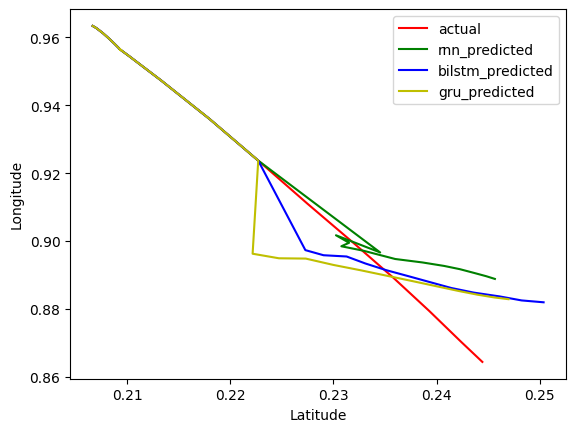

In [125]:
graphP(146)

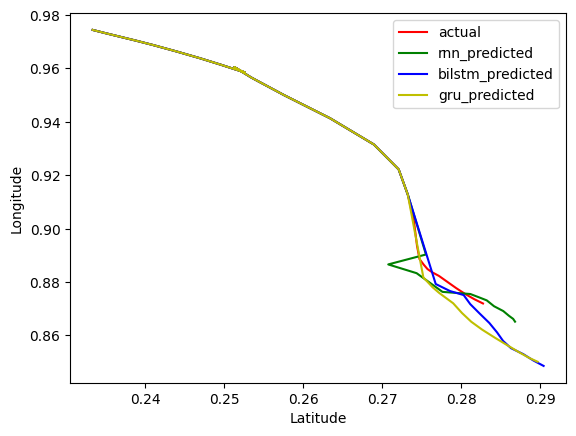

In [126]:
graphP(101)

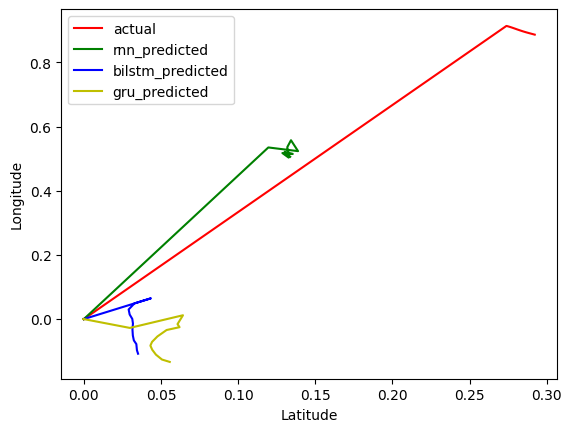

In [110]:
graphP(47)

In [111]:
print(x3)

NameError: name 'x3' is not defined